In [4]:
import scanpy as sc

adata = sc.read_10x_mtx(
    "/Users/prashammarfatia/Downloads",  # This folder contains matrix.mtx, genes.tsv, barcodes.tsv
    var_names="gene_symbols", 
    cache=True
)

# View the AnnData object summary
print(adata)

AnnData object with n_obs × n_vars = 32991 × 36601
    var: 'gene_ids'


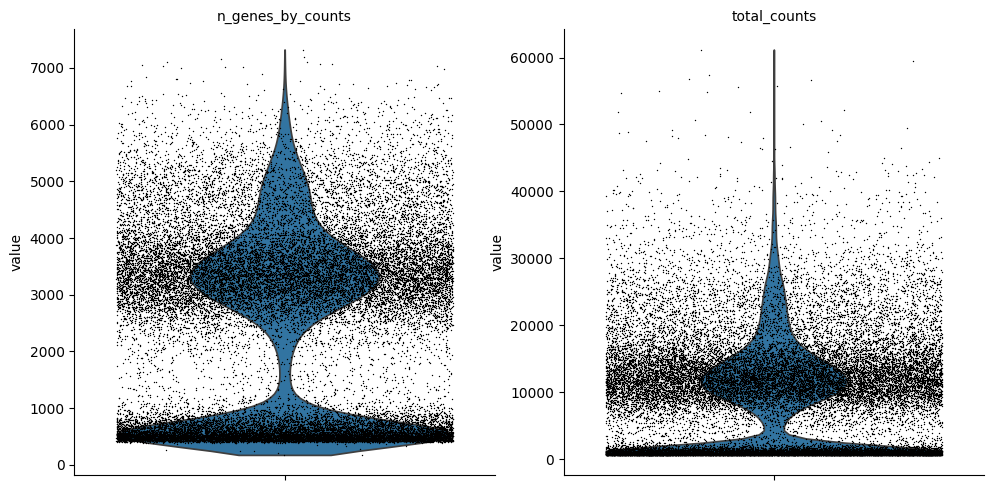

In [5]:
adata.raw = adata  # Backup raw counts
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)


In [3]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [5]:
adata[:10, :10].to_df()

,AL627309.1,AL627309.5,AL627309.4,AP006222.2,AL669831.2,LINC01409,FAM87B,LINC01128,LINC00115,FAM41C
AAACCCAAGAAGTCAT-1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
AAACCCAAGACACACG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGAGGACTC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGCATGATA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGCGTATAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGGTAAAGG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAAGTTCGCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCACAAATTGGA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCACAAGCTGCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCACAATCGCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
import pandas as pd

guide_path = "/Users/prashammarfatia/Downloads/GSM6435403_scRNAseq_2kG_11AMDox_1_noguidemut_calls.tsv.gz"

guide_df = pd.read_csv(guide_path, sep="\t")

guide_df.head()

,Unnamed: 0,CBC_10x,Guide,Gene,UMI_count,Good_singlet,Multiplet
0,6,AAACCCAAGAAGTCAT,GAAGGGACATCATTCACGCCT,ANKEF1,10,1,1
1,10,AAACCCAAGACACACG,GCCCTTCGTGGCCGCCCGGCG,CBX3,1,0,0
2,29,AAACCCAAGAGGACTC,GTGGTCCTGGGTACCGAGCAT,MTRR,13,1,1
3,69,AAACCCAAGCATGATA,NaN,NaN,0,0,0
4,95,AAACCCAAGCGTATAA,GCCAGGCTTCGTGGGACCAAC,DALRD3-TSS2,1,0,0


In [6]:
# 1. First, make sure barcodes are consistent (with the "-1" suffix)
guide_df["barcode"] = guide_df["CBC_10x"] + "-1"

# 2. Set index for the guide_df to barcodes
guide_df.set_index("barcode", inplace=True)

# 3. Subset guide_df to only cells present in adata
guide_df_sub = guide_df.loc[adata.obs_names.intersection(guide_df.index)]

# 4. Align the order of guide_df to match adata.obs
guide_df_sub = guide_df_sub.loc[adata.obs_names]

# 5. Add the relevant columns (Guide, Gene) to adata.obs
adata.obs["Guide"] = guide_df_sub["Guide"]
adata.obs["Gene"] = guide_df_sub["Gene"]

In [7]:
adata.obs[["Guide", "Gene"]].head(10)

,Guide,Gene
AAACCCAAGAAGTCAT-1,GAAGGGACATCATTCACGCCT,ANKEF1
AAACCCAAGACACACG-1,GCCCTTCGTGGCCGCCCGGCG,CBX3
AAACCCAAGAGGACTC-1,GTGGTCCTGGGTACCGAGCAT,MTRR
AAACCCAAGCATGATA-1,NaN,NaN
AAACCCAAGCGTATAA-1,GCCAGGCTTCGTGGGACCAAC,DALRD3-TSS2
AAACCCAAGGTAAAGG-1,GCGGCCGAGTTGGGAGAATG,GALNT2
AAACCCAAGTTCGCAT-1,NaN,NaN
AAACCCACAAATTGGA-1,NaN,NaN
AAACCCACAAGCTGCC-1,NaN,NaN
AAACCCACAATCGCAT-1,GATGCGCCCTGCCCGGCGTGC,JAG1
